# Point History Classifier Training Pipeline
This notebook completely rewrites the old training pipeline for finger gesture classification handling using modern TensorFlow 2.16 and Keras 3 APIs.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

## 1. Setup Environment
Let's set some random seeds for reproducibility.

In [2]:
def set_random_seeds(seed=42):
    """Sets random seeds for reproducibility across Python, NumPy, and TensorFlow."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_random_seeds(42)

# Determine the directory structure.
base_dir = os.path.abspath('')
model_dir = os.path.join(base_dir, 'model', 'point_history_classifier')

dataset_path = os.path.join(model_dir, 'point_history.csv')
keras_model_path = os.path.join(model_dir, 'point_history_classifier.keras')

print(f"Dataset Path: {dataset_path}")

Dataset Path: c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\point_history_classifier\point_history.csv


## 2. Load Dataset
The format is `label`, followed by normalized landmark arrays that record gesture trails over frames.

In [3]:
# Load the dataset
df = pd.read_csv(dataset_path, header=None)

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

num_classes = int(np.max(y) + 1)
print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features, {num_classes} classes.")

Dataset loaded: 5348 samples, 32 features, 5 classes.


## 3. Train/Test Split
We will split the dataset into an 80/20 train/test distribution.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (4278, 32)
Test data shape: (1070, 32)


## 4. Build Neural Network Model
For point history (shape=32), we use a slightly smaller capacity architecture than the main keypoint model to prevent overfitting on simple coordinates.

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,097 (4.29 KB)

 Trainable params: 1,097 (4.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Define Callbacks
We use standard Adam optimization with early stopping to prevent overfitting.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=keras_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## 6. Train the Model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,            
    batch_size=128,
    validation_split=0.2, 
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/100
17/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4104 - loss: 1.5949
Epoch 1: val_accuracy improved from None to 0.48248, saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\point_history_classifier\point_history_classifier.keras

Epoch 1: finished saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\point_history_classifier\point_history_classifier.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4287 - loss: 1.5865 - val_accuracy: 0.4825 - val_loss: 1.5626
Epoch 2/100
 1/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3750 - loss: 1.5639
Epoch 2: val_accuracy did not improve from 0.48248
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3182 - loss: 1.5456 - val_accuracy: 0.2558 - val_loss: 1.5203
Epoch 3/100
21/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3077 - loss: 1.5056 
Epoch 3: val_accuracy did not improve from 0.48248
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accura

## 7. Evaluate the Pipeline

In [8]:
# Get last epoch training and validation stats
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Get test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("\n--- Point History Training Results ---")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print("------------------------\n")


--- Point History Training Results ---
Training Accuracy:   0.9275
Validation Accuracy: 0.9556
Test Accuracy:       0.9729
------------------------



## 8. Generate Visualizations & Classifications

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       296
           1       0.99      0.99      0.99       247
           2       0.98      0.98      0.98       256
           3       0.95      0.96      0.95       261
           4       0.00      0.00      0.00        10

    accuracy                           0.97      1070
   macro avg       0.78      0.79      0.78      1070
weighted avg       0.96      0.97      0.97      1070



c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

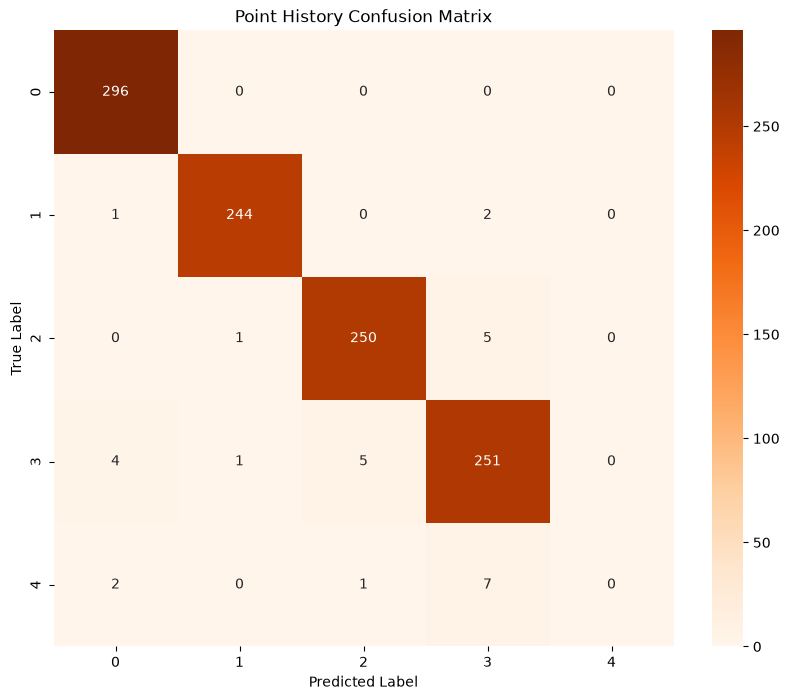

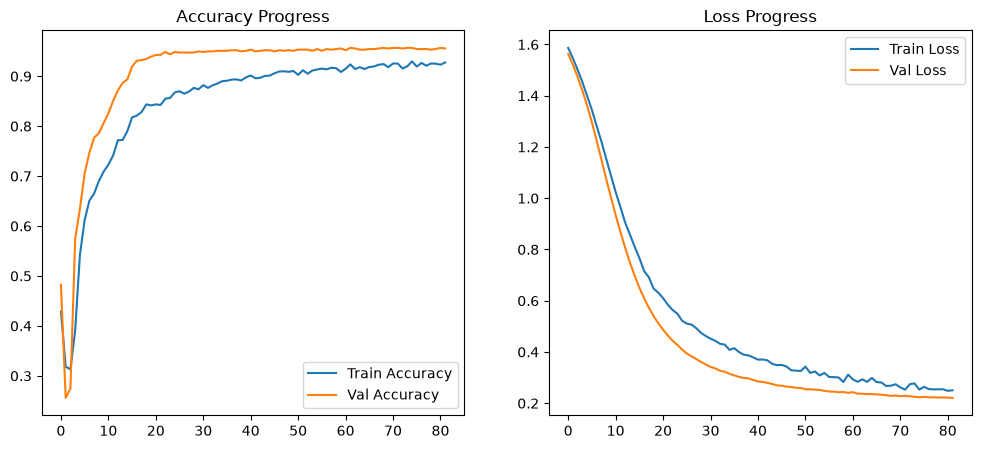

Point history notebook completed successfully.


In [9]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Point History Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Accuracy Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Progress')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Progress')
plt.legend()
plt.show()

print("Point history notebook completed successfully.")